In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

project_root = os.path.dirname(os.path.abspath(''))
if project_root not in sys.path:
    sys.path.append(project_root)

# from MODELS.xgboostModel import *
from MODELS.ngboostModel import *
from PRODUCTION.pipeline import *
from FEATURES.features import *

In [4]:
pd.set_option('display.max_columns', None)

def encode_teams(df):
    """One-hot encode opponent team."""
    df_opps = pd.get_dummies(df['OPP_ABBREVIATION'], prefix='OPP_').astype(int)
    df = pd.concat([df, df_opps], axis=1)  # Merge back with original dataframe
    return df

s19 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_19.csv')
s20 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_20.csv')
s21 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_21.csv')
s22 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_22.csv')
s23 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_23.csv')
s24 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_24.csv')
s25 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_25.csv')
s26 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_26.csv')

for df_name in ['s19', 's20', 's21', 's22', 's23', 's24', 's25', 's26']:
    df = globals()[df_name]
    df = add_opponent_defensive_difficulty(df)
    df = activate_matchup_stats(df)  # Now activate them
    df = encode_teams(df)
    globals()[df_name] = df  # Reassign back

# Backtesting Training data
train_df = pd.concat([s20,s21,s22,s23,s24,s25])
train_df = train_df[(train_df['MIN'] >= 10)]

# Backtesting Validation data
val_df = s26
val_df = val_df[(val_df['MIN'] >= 10)]


print(f"Train set: {len(train_df)} samples")
print(f"Val set: {len(val_df)} samples")

train_df.sample(5)

/var/folders/9q/5_554qsx5z70w9d_vkmvjg0h0000gn/T/ipykernel_96419/1062986481.py:16: DtypeWarning: Columns (33) have mixed types. Specify dtype option on import or set low_memory=False.
  s26 = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_26.csv')


Activated matchup stats for 12 metrics
Created 84 new matchup features
Activated matchup stats for 12 metrics
Created 84 new matchup features
Activated matchup stats for 12 metrics
Created 84 new matchup features
Activated matchup stats for 12 metrics
Created 84 new matchup features
Activated matchup stats for 12 metrics
Created 84 new matchup features
Activated matchup stats for 12 metrics
Created 84 new matchup features
Activated matchup stats for 12 metrics
Created 84 new matchup features
Activated matchup stats for 12 metrics
Created 84 new matchup features
Train set: 127312 samples
Val set: 4312 samples


Unnamed: 0      PLAYER_NAME  PLAYER_ID      MATCHUP TEAM_ABBREVIATION  \
19404       19404  Stanley Johnson    1626169  SAS vs. DAL               SAS   
20796       20796   Gary Payton II    1627780  WAS vs. BKN               WAS   
17241       17241      Jae Crowder     203109    PHX @ NOP               PHX   
1321         1321       Al Horford     201143    BOS @ IND               BOS   
6574         6574   Sterling Brown    1628425  HOU vs. BOS               HOU   

          TEAM_ID OPP_ABBREVIATION  HOME_GAME   GAME_ID   GAME_DATE WL  PTS  \
19404  1610612759              DAL          1  22200542  2022-12-31  L    6   
20796  1610612764              BKN          1  21900731  2020-02-01  W    4   
17241  1610612756              NOP          0  22101032  2022-03-15  W    9   
1321   1610612738              IND          0  22100618  2022-01-12  W    8   
6574   1610612745              BOS          1  22000598  2021-03-14  L    7   

       AST  REB  FGM  FGA  FG_PCT  FG3M  FG3A  FG3_PCT  FTM  FTA  FT_PCT  \
19404    2    3    2    4   0.500     0     2    0.000    2    4     0.5   
20796    3    5    2    7   0.286     0     2    0.000    0    1     0.0   
17241    4    3    3    6   0.500     3     6    0.500    0    0     NaN   
1321     4    4    4    8   0.500     0     3    0.000    0    0     NaN   
6574     1    1    2    7   0.286     1     6    0.167    2    2     1.0   

       OREB  DREB  STL  BLK  TOV  PLUS_MINUS  FANTASY_PTS  POINT_PER_SHOT  \
19404     0     3    0    0    2          -5         10.6           1.042   
20796     2     3    3    0    0           4         23.5           0.538   
17241     0     3    0    0    0          -1         18.6           1.500   
1321      1     3    0    0    0          17         18.8           1.000   
6574      0     1    1    0    0         -13         12.7           0.888   

            EFG START_POSITION  COMMENT  OFF_RATING  E_OFF_RATING  DEF_RATING  \
19404  0.500000            NaN      NaN         NaN         103.0         NaN   
20796  0.285714              F      NaN       111.1         111.1       102.2   
17241  0.750000              F      NaN         NaN         135.8         NaN   
1321   0.500000              F      NaN         NaN         128.2         NaN   
6574   0.357143              F      NaN         NaN         100.1         NaN   

       E_DEF_RATING  NET_RATING  OREB_PCT  DREB_PCT  REB_PCT  AST_PCT  \
19404         109.6        -7.8     0.000     0.200    0.103    0.154   
20796         102.2         8.9     0.063     0.111    0.085    0.167   
17241         133.8        -2.1     0.000     0.167    0.083    0.200   
1321          101.5        33.3     0.045     0.120    0.085    0.182   
6574          118.5       -22.2     0.000     0.032    0.015    0.050   

       EFG_PCT  AST_TOV  USG_PCT  TS_PCT  E_PACE    PACE    PIE  POSS  \
19404    0.500      1.0    0.182   0.521  101.49  106.59  0.071  37.0   
20796    0.286      0.0    0.125   0.269   99.91   99.91  0.077  45.0   
17241    0.750      0.0    0.122   0.750  101.61  103.01  0.090  47.0   
1321     0.500      0.0    0.136   0.500   94.49   88.75  0.091  51.0   
6574     0.357      0.0    0.111   0.444  103.79  105.28  0.045  64.0   

       PACE_PER40  E_USG_PCT    MIN   SPD  DIST  ORBC  DRBC   RBC  TCHS  SAST  \
19404       88.83      0.195  17.12  4.35  1.32   0.0   3.0   3.0  22.0   0.0   
20796       83.26      0.125  21.62  4.70  1.74   3.0   4.0   7.0  21.0   0.0   
17241       85.84      0.126  21.90  3.93  1.53   0.0   6.0   6.0  48.0   0.0   
1321        73.96      0.135  27.58  3.88  1.89   2.0   9.0  11.0  42.0   0.0   
6574        87.74      0.114  28.95  4.27  2.16   1.0   4.0   4.0  26.0   0.0   

       FTAST  PASS  CFGM  CFGA  CFG_PCT  UFGM  UFGA  UFG_PCT  DFGM  DFGA  \
19404    0.0  15.0   2.0   2.0      1.0   0.0   2.0    0.000   2.0   3.0   
20796    0.0  13.0   0.0   3.0      0.0   2.0   4.0    0.500   1.0   2.0   
17241    1.0  39.0   0.0   1.0      0.0   3.0   5.0

In [27]:
features = [
    # ===== CORE CONTEXT =====
    'STARTING',
    'PLAYER_IS_TEAM_STAR',
    'USUAL_STARTERS_AVAILABLE',
    'GAMES_PLAYED_TO_DATE',

    # ===== SEASON AVERAGES =====
    'PTS_AVG_TO_DATE', 
    'FGA_AVG_TO_DATE', 
    'FGM_AVG_TO_DATE', 
    'AST_AVG_TO_DATE',
    'USG_PCT_AVG_TO_DATE',
    'E_OFF_RATING_AVG_TO_DATE', 
    'FTA_AVG_TO_DATE', 
    'FTM_AVG_TO_DATE',
    'FG3A_AVG_TO_DATE',
    'FG3M_AVG_TO_DATE',
    'TCHS_AVG_TO_DATE',
    'POSS_AVG_TO_DATE',
    'UFGA_AVG_TO_DATE',
    'UFGM_AVG_TO_DATE',
    'CFGA_AVG_TO_DATE',
    'CFGM_AVG_TO_DATE',
    'DIST_AVG_TO_DATE',
    'SPD_AVG_TO_DATE',
    'DFGA_AVG_TO_DATE', 
    'DFGM_AVG_TO_DATE',
    'PIE_AVG_TO_DATE', 

    # ===== LAGS =====
    'STARTING_LAG_1',
    'STARTING_LAG_2',
    'PTS_LAG_1',
    'FGA_LAG_1',
    'POSS_LAG_1',
    'POSS_LAG_2',
    'MIN_LAG_1',
    'USG_PCT_LAG_1',
    'TCHS_LAG_1',
    'CFGA_LAG_1',
    'UFGA_LAG_1',
    
    # ===== ROLLING AVERAGES =====
    'PTS_ROLLING_AVG_3',
    'PTS_ROLLING_AVG_5', 
    'PTS_ROLLING_AVG_10',
    'PTS_ROLLING_AVG_20', 
    'MIN_ROLLING_AVG_3',
    'MIN_ROLLING_AVG_5', 
    'USG_PCT_ROLLING_AVG_3',
    'USG_PCT_ROLLING_AVG_5', 
    'USG_PCT_ROLLING_AVG_10',
    'FGA_ROLLING_AVG_3',
    'FGA_ROLLING_AVG_5', 
    'FGA_ROLLING_AVG_10', 
    'FGA_ROLLING_AVG_20', 
    'FGM_ROLLING_AVG_10',
    'FGM_ROLLING_AVG_20',
    'FG3A_ROLLING_AVG_5', 
    'FG3A_ROLLING_AVG_10', 
    'FG3A_ROLLING_AVG_20', 
    'FTA_ROLLING_AVG_3',
    'FTA_ROLLING_AVG_5', 
    'FTA_ROLLING_AVG_10', 
    'FTA_ROLLING_AVG_20',
    'E_OFF_RATING_ROLLING_AVG_5',
    'E_OFF_RATING_ROLLING_AVG_10',
    'E_OFF_RATING_ROLLING_AVG_20',
    'NET_RATING_ROLLING_AVG_5', 
    'NET_RATING_ROLLING_AVG_10',
    'NET_RATING_ROLLING_AVG_20', 
    'UFGA_ROLLING_AVG_5',
    'UFGA_ROLLING_AVG_10',
    'CFGA_ROLLING_AVG_5',
    'CFGA_ROLLING_AVG_10',
    'POSS_ROLLING_AVG_3',
    'POSS_ROLLING_AVG_5',
    'POSS_ROLLING_AVG_10',
    'POSS_ROLLING_AVG_20',
    'TCHS_ROLLING_AVG_3',
    'TCHS_ROLLING_AVG_5',
    'TCHS_ROLLING_AVG_10',
    'TCHS_ROLLING_AVG_20',
    'DIST_ROLLING_AVG_3',
    'DIST_ROLLING_AVG_5',
    'DIST_ROLLING_AVG_10',
    'DIST_ROLLING_AVG_20',
    'percentageUnassistedFGM_ROLLING_AVG_10',
    'percentageUnassistedFGM_ROLLING_AVG_20',
    'percentageAssistedFGM_ROLLING_AVG_10',
    'percentageAssistedFGM_ROLLING_AVG_20',
    
    # ===== VOLATILITY =====
    'MIN_VOLATILITY_5_TO_DATE',
    'MIN_VOLATILITY_10_TO_DATE',
    'MIN_VOLATILITY_20_TO_DATE', 
    'PTS_VOLATILITY_5_TO_DATE',
    'PTS_VOLATILITY_10_TO_DATE', 
    'PTS_VOLATILITY_20_TO_DATE',
    'FGA_VOLATILITY_5_TO_DATE',
    'FGA_VOLATILITY_10_TO_DATE',
    'FGA_VOLATILITY_20_TO_DATE',
    'FTA_VOLATILITY_5_TO_DATE',
    'FTA_VOLATILITY_10_TO_DATE',
    'FTA_VOLATILITY_20_TO_DATE',
    'FG3A_VOLATILITY_5_TO_DATE',
    'FG3A_VOLATILITY_10_TO_DATE',
    'FG3A_VOLATILITY_20_TO_DATE',
    'USG_PCT_CV_5_TO_DATE',
    'USG_PCT_CV_10_TO_DATE', 
    'USG_PCT_CV_20_TO_DATE', 
    'TS_PCT_CV_10_TO_DATE',
    'TS_PCT_CV_20_TO_DATE', 
    'PACE_VOLATILITY_5_TO_DATE',
    'PACE_VOLATILITY_10_TO_DATE',
    'PACE_VOLATILITY_20_TO_DATE',
    'E_OFF_RATING_VOLATILITY_5_TO_DATE',
    'E_OFF_RATING_VOLATILITY_10_TO_DATE',
    'E_OFF_RATING_VOLATILITY_20_TO_DATE',
    'POSS_VOLATILITY_5_TO_DATE',
    'POSS_VOLATILITY_10_TO_DATE',
    'POSS_VOLATILITY_20_TO_DATE',
    'TCHS_VOLATILITY_5_TO_DATE',
    'TCHS_VOLATILITY_10_TO_DATE',
    'TCHS_VOLATILITY_20_TO_DATE',
    'DIST_VOLATILITY_5_TO_DATE',
    'DIST_VOLATILITY_10_TO_DATE',
    'DIST_VOLATILITY_20_TO_DATE',

    # ===== MIN/MAX (Useful extremes) =====
    'MIN_MAX_LAST_10', 
    'MIN_MIN_LAST_10',
    'MIN_MIN_LAST_20',
    'PTS_MIN_LAST_10',
    'PTS_MAX_LAST_10',
    'PTS_MIN_LAST_20',
    'PTS_MAX_LAST_20',
    'USG_PCT_MAX_LAST_10',
    'USG_PCT_MIN_LAST_10',
    'TS_PCT_MAX_LAST_10',
    'PTS_RANGE_10', 
    'USG_PCT_RANGE_10', 
    'TS_PCT_RANGE_10', 
    
    # ==== Short vs long term divergences =====
    'PTS_10G_VS_SEASON_RATIO',
    'PTS_10G_VS_40G_RATIO', 
    'MIN_10G_VS_SEASON_RATIO',
    'MIN_10G_VS_40G_RATIO', 
    'USG_PCT_10G_VS_SEASON_RATIO',
    'USG_PCT_10G_VS_40G_RATIO',
    'TS_PCT_10G_VS_SEASON_RATIO',
    'TS_PCT_10G_VS_40G_RATIO',
    'FGA_10G_VS_SEASON_RATIO',
    'FGA_10G_VS_40G_RATIO',
    'TCHS_5G_VS_SEASON_RATIO',
    'TCHS_10G_VS_40G_RATIO',

    # === Consistency metrics =====
    'PTS_CONSISTENCY', 
    'MIN_CONSISTENCY',
    'USG_PCT_CONSISTENCY', 
    
    # === Variance stability metrics =====
    'VARIANCE_STABILITY',
    'MIN_VARIANCE_STABILITY', 
    'USG_PCT_VARIANCE_STABILITY', 
    'TS_PCT_VARIANCE_STABILITY', 
    'FTA_VARIANCE_STABILITY', #new
    'FGA_VARIANCE_STABILITY', #new
    'FG3A_VARIANCE_STABILITY', #new
    
    # ===== TRENDS =====
    'PTS_TREND_LAST_5',
    'MIN_TREND_LAST_5',
    'PTS_TREND_LAST_10',
    'MIN_TREND_LAST_10',
    
    # ===== INTERACTIONS =====
    'PTS_PER_MIN_X_USG',
    'USAGE_X_EFFICIENCY',
    'USAGE_X_MINUTES',
    'PTS_PER_POSSESSION',
    'B2B_X_MIN_LAST_5',
    'USG_PCT_X_STAR_SAT_OUT',
    'TCHS_X_USG',
    'DIST_PER_MIN',
    'TCHS_PER_MIN',
    'SHOT_QUALITY_RATIO',
    'UNCONTESTED_SHOTS_RATIO',
    'CONTESTED_SHOTS_RATIO',
    
    # # ===== SHOT PROFILE =====
    'percentagePointsMidrange2pt_AVG_TO_DATE',
    'percentagePointsPaint_AVG_TO_DATE',
    'percentagePoints3pt_AVG_TO_DATE',
    'percentagePoints2pt_AVG_TO_DATE',
    'percentageUnassisted3pt_AVG_TO_DATE',
    'percentageAssistedFGM_AVG_TO_DATE',
    'percentageAssisted3pt_AVG_TO_DATE',
    'percentageFieldGoalsAttempted2pt_AVG_TO_DATE',
    'percentageFieldGoalsAttempted3pt_AVG_TO_DATE',
    
    # ===== STAR DYNAMICS =====
    'PTS_BOOST_STAR_OUT',
    'USG_PCT_BOOST_STAR_OUT',
    'MIN_BOOST_STAR_OUT',
    'FGA_BOOST_STAR_OUT',
    'FTA_BOOST_STAR_OUT',
    'FG3A_BOOST_STAR_OUT',
    'UFGA_BOOST_STAR_OUT',
    'UFGM_BOOST_STAR_OUT',
    'CFGA_BOOST_STAR_OUT',
    'CFGM_BOOST_STAR_OUT',
    'DFGA_BOOST_STAR_OUT',
    'DFGM_BOOST_STAR_OUT',
    'TCHS_BOOST_STAR_OUT',
    'POSS_BOOST_STAR_OUT',
    'EFG_PCT_BOOST_STAR_OUT',
    'GAMES_WITHOUT_STAR',
    
    # ===== TIERS =====
    'IS_LOW_SCORER',
    'IS_MEDIUM_SCORER',
    'IS_HIGH_SCORER', 
    'LOW_MINUTE_PLAYER',
    'MEDIUM_MINUTE_PLAYER',
    'HIGH_MINUTE_PLAYER',
    'HIGH_VOLUME_PLAYER',
    'MEDIUM_VOLUME_PLAYER',
    'LOW_VOLUME_PLAYER',
    'CATCH_AND_SHOOT_SPECIALIST',
    'SHOT_CREATION_SPECIALIST',
    'RIM_ATTACKER',
    'PURE_PLAYMAKER',
    'ULTIMATE_TEAM_PLAYER',
    'FLOOR_SPACER',
    'ROLL_MAN',
    'ENERGY_PLAYER',

    # ===== TEAM CONTEXT =====
    'TEAM_PTS_ROLLING_AVG_3', 
    'TEAM_PTS_ROLLING_AVG_5',
    'TEAM_AST_ROLLING_AVG_3',
    'TEAM_AST_ROLLING_AVG_5',
    'TEAM_AST_ROLLING_AVG_10',
    'TEAM_OFF_RATING_ROLLING_AVG_3', 
    'TEAM_OFF_RATING_ROLLING_AVG_5',
    'TEAM_OFF_RATING_ROLLING_AVG_20',
    'TEAM_OFF_RATING_AVG_TO_DATE',
    'TEAM_PACE_ROLLING_AVG_3',
    'TEAM_DEF_RATING_ROLLING_AVG_3',
    'TEAM_DEF_RATING_ROLLING_AVG_5',
    'TEAM_FTA_ROLLING_AVG_3',
    
    # ===== OPPONENT =====
    'OPP_DEF_RATING_AVG_TO_DATE',
    'OPP_PACE_AVG_TO_DATE',
    'OPP_TEAM_DEF_RATING_ROLLING_AVG_5',
    'OPP_TEAM_PACE_ROLLING_AVG_5',
    'OPP_TOV_AVG_TO_DATE',
    'OPP_BLK_AVG_TO_DATE',
    'OPP_STL_AVG_TO_DATE',

    'OPP_DEF_DIFFICULTY_SCORE',
    'OPP_DEF_DIFFICULTY_COMBINED',
    'OPP_POSITION_DEF_DIFFICULTY',
    'OPP_POSITION_3PT_DEF_DIFFICULTY',
    'VS_ELITE_DEF',
    'VS_GOOD_DEF',
    'VS_AVERAGE_DEF',
    'VS_POOR_DEF',
    'DEF_DIFFICULTY_X_VOLUME',
    'DEF_DIFFICULTY_X_CATCH_SHOOT',
    'DEF_DIFFICULTY_X_SHOT_CREATOR',
    
    # ===== MATCHUP INTERACTIONS =====
    'PLAYER_X_MATCHUP_GUARD_FG_PCT',
    'PLAYER_3PT_RATE_X_OPP_GUARD_3PT_DEF_ALLOWED',
    'OPP_GUARD_PTS_ALLOWED_PER_MIN',
    'PLAYER_X_MATCHUP_FORWARD_FG_PCT',
    'PLAYER_3PT_RATE_X_OPP_FORWARD_3PT_DEF_ALLOWED',
    'OPP_FORWARD_PTS_ALLOWED_PER_MIN',
    'PLAYER_X_MATCHUP_CENTER_FG_PCT',
    'PLAYER_3PT_RATE_X_OPP_CENTER_3PT_DEF_ALLOWED',
    'OPP_CENTER_PTS_ALLOWED_PER_MIN',
    
    # ===== GAME CONTEXT =====
    'TEAM_OFF_MINUS_OPP_DEF',
    'EXPECTED_PACE',
    'PACE_DIFFERENTIAL',
    
    # ===== HOME/AWAY & MATCHUP =====
    'PTS_EXPECTATION_LOCATION',
    'USG_PCT_EXPECTATION_LOCATION',
    'EFG_PCT_EXPECTATION_LOCATION',
    'FGA_EXPECTATION_LOCATION',
    'FTA_EXPECTATION_LOCATION',
    'FG3A_EXPECTATION_LOCATION',
    'POSS_EXPECTATION_LOCATION',
    'TCHS_EXPECTATION_LOCATION',
    
    # # ===== MATCHUP =====
    'MATCHUP_AVG_PTS_TO_DATE', 
    'MATCHUP_AVG_FGA_TO_DATE',
    'MATCHUP_AVG_FGM_TO_DATE',
    'MATCHUP_AVG_FG3A_TO_DATE',
    'MATCHUP_AVG_FG3M_TO_DATE',
    'MATCHUP_AVG_FTA_TO_DATE',
    'MATCHUP_AVG_FTM_TO_DATE',
    'MATCHUP_AVG_MIN_TO_DATE',
    'MATCHUP_AVG_USG_PCT_TO_DATE',
    'MATCHUP_AVG_TS_PCT_TO_DATE',
    'MATCHUP_AVG_EFG_PCT_TO_DATE',
    'GAMES_VS_OPP', 
    
    'MATCHUP_PTS_RATIO',
    'MATCHUP_FGA_RATIO',
    'MATCHUP_FG3A_RATIO',
    'MATCHUP_FTA_RATIO',
    'MATCHUP_MIN_RATIO',
    'MATCHUP_USG_PCT_RATIO',
    'MATCHUP_EFG_PCT_RATIO',
    'MATCHUP_PTS_DELTA',
    'MATCHUP_FGA_DELTA',
    'MATCHUP_MIN_DELTA',
    'MATCHUP_USG_PCT_DELTA',
    'MATCHUP_PTS_ADVANTAGE',
    'MATCHUP_ADVANTAGE_OVERALL',
    'MATCHUP_PTS_RATIO_X_VOLUME',
    'MATCHUP_PTS_RATIO_X_DEF_DIFFICULTY',

    'OPP__ATL', 'OPP__BKN', 'OPP__BOS', 
    'OPP__CHA', 'OPP__CHI', 'OPP__CLE', 
    'OPP__DAL', 'OPP__DEN', 'OPP__DET', 
    'OPP__GSW', 'OPP__HOU', 'OPP__IND', 
    'OPP__LAC', 'OPP__LAL', 'OPP__MEM', 
    'OPP__MIA', 'OPP__MIL', 'OPP__MIN', 
    'OPP__NOP', 'OPP__NYK', 'OPP__OKC', 
    'OPP__ORL', 'OPP__PHI', 'OPP__PHX', 
    'OPP__POR', 'OPP__SAC', 'OPP__SAS', 
    'OPP__TOR', 'OPP__UTA', 'OPP__WAS',
    
]
print(f"Enhanced features: {len(features)}")

Enhanced features: 320


In [ ]:
# columns = train_df.columns.tolist()
# guardIDX = columns.index('GUARD')
# features = columns[guardIDX + 1:]
# numeric_columns = train_df.select_dtypes(include=[np.number]).columns.tolist()
# features = [col for col in features if col in numeric_columns]
# newFeatures = features

In [ ]:
from MODELS.xgboostModel import *

X_selected, selected_features, importance_df = select_features_ngboost(
    X=train_df[features],
    y=train_df['PTS'],
    top_n=100,     # Select more features
    n_runs=5,    # More runs for stability
    validate_both_distributions=True
)

In [ ]:
variance_important = importance_df[
    (importance_df['variance_importance'] > importance_df['mean_importance']) &
    (importance_df['variance_importance'] > 0.01)
].sort_values('variance_importance', ascending=False)

print("\nFeatures important for uncertainty:")
print(variance_important[['feature', 'variance_importance', 'mean_importance']])

# NGBOOST MODEL

### Remove correlated features

In [25]:
# from MODELS.xgboostModel import *
# corr_matrix, top_10_features = correlation_analysis(train_df, top_features)

final_features = remove_highly_correlated_features(train_df, features, threshold=0.995)


SUMMARY:
Original features: 320
Removed features: 0
Final features: 319


### NGBOOST MODEL

SPLIT NGBOOST

In [26]:

mean_model, variance_model, cal_factor = fit_ngboost_split(
train_df,
val_df,
final_features,
target_col='PTS',
distribution=Normal,
player_col='PLAYER_ID',
recent_n=20,
recent_weight=2.0,
variance_recent_weight=1.0,
variance_lr=0.02,  
variance_max_depth=8,  
variance_n_estimators=800,
variance_calibration_factor=4.5)


Using passed validation data to check for early stopping.
Using passed validation data to check for early stopping.


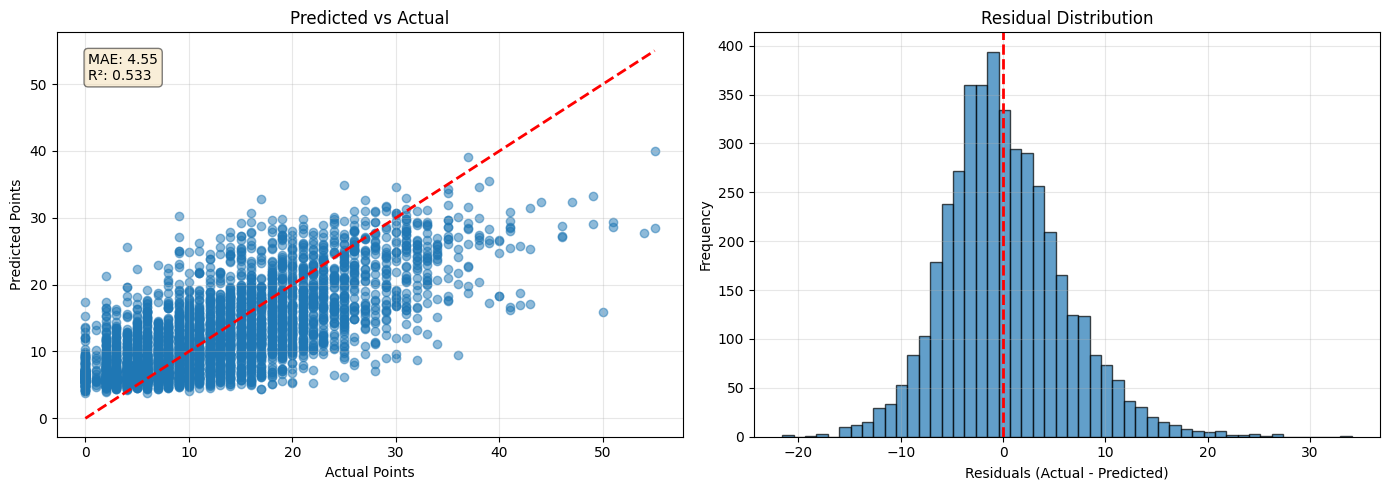

In [30]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score

preds_dist = mean_model.pred_dist(val_df[final_features])
y_pred_mean = preds_dist.loc
y_pred_std = preds_dist.scale
y_true = val_df['PTS'].values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


axes[0].scatter(y_true, y_pred_mean, alpha=0.5)
axes[0].plot([y_true.min(), y_true.max()], 
             [y_true.min(), y_true.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Points')
axes[0].set_ylabel('Predicted Points')
axes[0].set_title('Predicted vs Actual')
axes[0].grid(True, alpha=0.3)

mae = mean_absolute_error(y_true, y_pred_mean)
r2 = r2_score(y_true, y_pred_mean)
axes[0].text(0.05, 0.95, f'MAE: {mae:.2f}\nR²: {r2:.3f}', 
             transform=axes[0].transAxes,
             verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

residuals = y_true - y_pred_mean
axes[1].hist(residuals, bins=50, edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Residuals (Actual - Predicted)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [40]:
mean_importance_raw = mean_model.feature_importances_  
var_importance_raw = variance_model.feature_importances_    

# Average across the 2 distributions
mean_importance = mean_importance_raw.mean(axis=0)  
var_importance = var_importance_raw.mean(axis=0)    

# NOW create the DataFrame
feature_importance_df = pd.DataFrame({
    'feature': final_features,
    'mean_model': mean_importance,  
    'var_model': var_importance    
}).sort_values('mean_model', ascending=False)

# Display top features
print("\n" + "="*80)
print("Bottom 50 FEATURES FOR PREDICTING POINTS (MEAN MODEL)")
print("="*80)
print(feature_importance_df[['feature', 'mean_model']].tail(100).to_string(index=False))


Bottom 50 FEATURES FOR PREDICTING POINTS (MEAN MODEL)
                                     feature  mean_model
                     UNCONTESTED_SHOTS_RATIO    0.001342
                             FTA_AVG_TO_DATE    0.001339
                         POSS_BOOST_STAR_OUT    0.001295
                         DFGA_BOOST_STAR_OUT    0.001287
                                  CFGA_LAG_1    0.001281
                          MATCHUP_FG3A_RATIO    0.001269
             percentagePoints3pt_AVG_TO_DATE    0.001255
          MATCHUP_PTS_RATIO_X_DEF_DIFFICULTY    0.001252
                          CFGA_ROLLING_AVG_5    0.001248
                         USG_PCT_CONSISTENCY    0.001247
                         DIST_ROLLING_AVG_20    0.001242
      percentageUnassistedFGM_ROLLING_AVG_20    0.001226
                       MATCHUP_USG_PCT_DELTA    0.001196
                           MATCHUP_MIN_RATIO    0.001166
                             PTS_MAX_LAST_10    0.001166
                   MIN_VOLATILITY

In [36]:
feature_importance_df = pd.DataFrame({
    'feature': final_features,
    'mean_model': mean_importance,  
    'var_model': var_importance    
}).sort_values('var_model', ascending=False)


print("\n" + "="*80)
print("Bottom 50 FEATURES FOR PREDICTING POINTS (VAR MODEL)")
print("="*80)
print(feature_importance_df[['feature', 'var_model']].head(50).to_string(index=False))


Bottom 50 FEATURES FOR PREDICTING POINTS (VAR MODEL)
                          feature  var_model
                    IS_LOW_SCORER   0.023767
               FGA_ROLLING_AVG_20   0.014380
               FGA_ROLLING_AVG_10   0.013834
   TEAM_OFF_RATING_ROLLING_AVG_20   0.010667
  OPP_FORWARD_PTS_ALLOWED_PER_MIN   0.009308
                MIN_TREND_LAST_10   0.009085
    TEAM_DEF_RATING_ROLLING_AVG_3   0.008803
                PACE_DIFFERENTIAL   0.008306
        PACE_VOLATILITY_5_TO_DATE   0.007868
           TEAM_PTS_ROLLING_AVG_3   0.007863
      OPP_TEAM_PACE_ROLLING_AVG_5   0.007821
   OPP_CENTER_PTS_ALLOWED_PER_MIN   0.007760
    OPP_GUARD_PTS_ALLOWED_PER_MIN   0.007726
    TEAM_DEF_RATING_ROLLING_AVG_5   0.007579
      TEAM_OFF_RATING_AVG_TO_DATE   0.007455
              UFGA_ROLLING_AVG_10   0.007440
                    EXPECTED_PACE   0.007376
                 DFGM_AVG_TO_DATE   0.007252
          DEF_DIFFICULTY_X_VOLUME   0.007194
    TEAM_OFF_RATING_ROLLING_AVG_3   0.007139
 

In [34]:
validate_production_model(mean_model, variance_model, val_df, final_features, 'PTS', cal_factor)

=== CALIBRATION CHECK ===
Standardized residuals mean: 0.019 (should be ~0)
Standardized residuals std: 0.975 (should be ~1)
Q25: Predicted=8.3, Actual=6.0
Q50: Predicted=12.3, Actual=11.0
Q75: Predicted=16.3, Actual=17.0

MAE: 4.55
90% CI: Coverage=91.67%, Expected=90.00%
95% CI: Coverage=95.62%, Expected=95.00%
99% CI: Coverage=98.52%, Expected=99.00%


array([-0.63230732,  0.49171577,  1.2528846 , ...,  1.27372709,
        0.10810617, -1.2867355 ], shape=(4312,))

In [41]:
import joblib

# Save NGBoost split models (mean, variance, calibration factor)
joblib.dump(mean_model, 'SAVED_MODELS/NGBOOST_PTS_MEAN_MODEL_PRODUCTIONV2.pkl')
joblib.dump(variance_model, 'SAVED_MODELS/NGBOOST_PTS_VAR_MODEL_PRODUCTIONV2.pkl')
joblib.dump(cal_factor, 'SAVED_MODELS/NGBOOST_PTS_CALIBRATION_FACTOR_PRODUCTIONV2.pkl')

joblib.dump(features, 'SAVED_MODELS/feature_listV2.pkl')

print("="*80)
print("Models saved successfully!")
print("="*80)
print("✓ Mean model")
print("✓ Variance model")
print("✓ Calibration factor")
print("✓ Feature list")

Models saved successfully!
✓ Mean model
✓ Variance model
✓ Calibration factor
✓ Feature list


In [24]:
# import joblib

# # Save NGBoost split models (mean, variance, calibration factor)
# joblib.dump(mean_model, 'SAVED_MODELS/NGBOOST_PTS_MEAN_MODEL_BACKTEST.pkl')
# joblib.dump(variance_model, 'SAVED_MODELS/NGBOOST_PTS_VAR_MODEL_BACKTEST.pkl')
# joblib.dump(cal_factor, 'SAVED_MODELS/NGBOOST_PTS_CALIBRATION_FACTOR_BACKTEST.pkl')

# joblib.dump(features, 'SAVED_MODELS/feature_list.pkl')

# print("="*80)
# print("Models saved successfully!")
# print("="*80)
# print("✓ Mean model")
# print("✓ Variance model")
# print("✓ Calibration factor")
# print("✓ Feature list")

Models saved successfully!
✓ Mean model
✓ Variance model
✓ Calibration factor
✓ Feature list
